## **CST8508 Machine Vision - Lab 1 - Image Processing with OpenCV**


**Materials Required:**

Computers with Python and OpenCV installed,
Sample images for processing

**Lab Duration:** 2 hours

**Part 1: Introduction to OpenCV**

Brief overview of OpenCV and its applications in Machine Vision.
Basic commands in OpenCV: Reading, displaying, and writing images.

**Exercise 1:** Load and display an image. Then, save this image in a different format (e.g., from JPEG to PNG). Let's also display it!

Hint: cv2.imshow() does not work in Google Colab. Search for an alternative

In [99]:
import cv2
from matplotlib import pyplot as plt

def load_and_write_and_display_image(image_path):
    # Requirement: Load and display an image, then save in different format (JPEG to PNG)
    # Load image from file path
    # 要求：加载并显示图像，然后保存为不同格式（JPEG 转 PNG）
    # 从文件路径加载图像
    img = cv2.imread(image_path)
    
    # Requirement: Save image in PNG format
    # Convert format to meet assignment requirements
    # 要求：将图像保存为 PNG 格式
    # 转换格式以满足作业要求
    cv2.imwrite('output.png', img)
    
    # Requirement: Display the image
    # Convert BGR to RGB because OpenCV uses BGR while matplotlib expects RGB, preventing red-blue color swap
    # 要求：显示图像
    # 将 BGR 转换为 RGB，因为 OpenCV 使用 BGR 而 matplotlib 期望 RGB，防止红蓝颜色互换
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title('Loaded Image')
    plt.show()
    
    return img


**Part 2: Image Manipulations**

Understanding image color spaces and conversions (RGB, Grayscale, HSV).
Performing basic image manipulations: resizing, cropping, and rotating images.

**Exercise 2:** Convert an image from RGB to Grayscale and then crop, rotate, flip vertically and resize it.


In [100]:
def convert_to_grayscale_and_manipulate(image_path, new_size, rotate_angle, roi):
    # Requirement: Convert image from RGB to Grayscale
    # Load image from file
    # 要求：将图像从 RGB 转换为灰度图
    # 从文件加载图像
    img = cv2.imread(image_path)
    # Convert to grayscale to reduce color information for easier processing
    # 转换为灰度图以减少颜色信息，便于处理
    gray_image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Requirement: Crop the image
    # Crop region of interest (ROI) to extract specific area from original grayscale
    # 要求：裁剪图像
    # 从原始灰度图裁剪感兴趣区域（ROI）以提取特定区域
    # x: left-top x coordinate, y: left-top y coordinate, w: width, h: height
    # x: 左上角x坐标, y: 左上角y坐标, w: 宽度, h: 高度
    x, y, w, h = roi
    # Extract rectangle from (x,y) to (x+w, y+h)
    # 从(x,y)到(x+w, y+h)提取矩形区域
    gray_cropped_image = gray_image[y:y+h, x:x+w]
    
    # Requirement: Rotate the image
    # Rotate original grayscale around center point to change image orientation
    # 要求：旋转图像
    # 围绕中心点旋转原始灰度图以改变图像方向
    # Get image height and width
    # 获取图像高度和宽度
    height, width = gray_image.shape
    # Calculate center point coordinates for rotation
    # 计算旋转中心点坐标
    center = (width // 2, height // 2)
    # Create rotation matrix: center point, rotation angle (degrees), scale factor (1.0 = no scaling)
    # 创建旋转矩阵：中心点、旋转角度（度数）、缩放因子（1.0 = 不缩放）
    rotation_matrix = cv2.getRotationMatrix2D(center, rotate_angle, 1.0)
    # Apply rotation transformation to image
    # 对图像应用旋转变换
    gray_rotated_image = cv2.warpAffine(gray_image, rotation_matrix, (width, height))
    
    # Requirement: Flip vertically
    # Flip original grayscale vertically (0 means vertical flip) to create mirror effect
    # 要求：垂直翻转
    # 垂直翻转原始灰度图（0 表示垂直翻转）以创建镜像效果
    gray_flipped_image = cv2.flip(gray_image, 0)
    
    # Requirement: Resize the image
    # Resize original grayscale to new dimensions for display or processing needs
    # 要求：调整图像大小
    # 调整原始灰度图到新尺寸以满足显示或处理需求
    gray_resized_image = cv2.resize(gray_image, new_size)
    
    return gray_cropped_image, gray_rotated_image, gray_flipped_image, gray_resized_image

**Part 3: Image Filtering and Edge Detection**

Understanding the concept of image filtering and its applications.
Implementing basic filters: Gaussian blur, median blur.
Introduction to edge detection: Sobel and Canny edge detectors.


**Exercise 3**: Apply a Gaussian blur to an image and then perform edge detection using the Canny algorithm.



In [101]:
def apply_gaussian_blur_and_edge_detection(image_path, blur_ksize, edge_threshold1, edge_threshold2):
    # Requirement: Apply Gaussian blur and perform edge detection using Canny algorithm
    # Load image from file
    # 要求：应用高斯模糊并使用 Canny 算法进行边缘检测
    # 从文件加载图像
    img = cv2.imread(image_path)
    
    # Requirement: Apply Gaussian blur
    # Reduce noise before edge detection to prevent false edge points caused by image noise
    # 要求：应用高斯模糊
    # 边缘检测前降噪以防止图像噪声导致的误判边缘点
    # Note: Gaussian blur uses weighted average, good for general noise reduction
    # Alternative: Median blur (cv2.medianBlur) uses median value, better for salt-and-pepper noise
    # 注意：高斯模糊使用加权平均，适合一般降噪
    # 替代方案：中值模糊（cv2.medianBlur）使用中值，更适合椒盐噪声
    blurred_image = cv2.GaussianBlur(img, (blur_ksize, blur_ksize), 0)
    
    # Requirement: Perform edge detection using Canny algorithm
    # Detect edges using two thresholds to identify strong and weak edges
    # 要求：使用 Canny 算法进行边缘检测
    # 使用两个阈值检测边缘以识别强边缘和弱边缘
    # Note: Canny is multi-stage algorithm with two thresholds (strong/weak edges)
    # Alternative: Sobel (cv2.Sobel) is gradient-based, calculates edge intensity in x/y directions
    # 注意：Canny 是多阶段算法，使用两个阈值检测强/弱边缘
    # 替代方案：Sobel（cv2.Sobel）基于梯度，计算 x/y 方向的边缘强度
    edge_detected_image = cv2.Canny(blurred_image, edge_threshold1, edge_threshold2)
    
    return edge_detected_image

**Testing the Functions**

Download a sample image and test all three exercises:

In [102]:
import urllib.request
import os

# Download sample image from OpenCV repository | 从 OpenCV 仓库下载示例图像
image_url = 'https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg'
image_path = 'sample_image.jpg'

try:
    # Download and save image locally | 下载并保存图像到本地
    urllib.request.urlretrieve(image_url, image_path)
    print(f'Downloaded image to {image_path}')
    print(f'File exists: {os.path.exists(image_path)}')
except Exception as e:
    print(f'Error downloading image: {e}')

Downloaded image to sample_image.jpg
File exists: True


Exercise 1: Load and Display Image


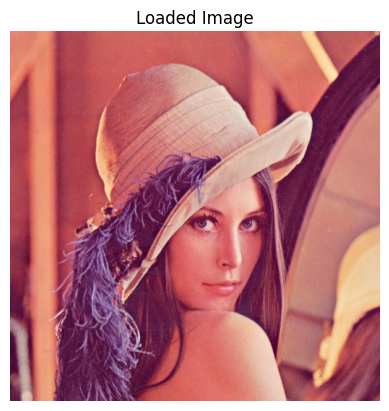

Exercise 1 completed successfully


In [103]:
# Test Exercise 1: Load, save, and display image | 测试练习 1：加载、保存和显示图像
print('Exercise 1: Load and Display Image')
try:
    img = load_and_write_and_display_image(image_path)
    print('Exercise 1 completed successfully')
except Exception as e:
    print(f'Error in Exercise 1: {e}')

Exercise 2: Grayscale and Manipulations
Original image size: 512x512 (width x height)
原始图像大小: 512x512 (宽 x 高)
Cropped size: 200x200
Rotated size: 512x512
Flipped size: 512x512
Resized size: 300x300
裁剪后大小: 200x200
旋转后大小: 512x512
翻转后大小: 512x512
调整后大小: 300x300


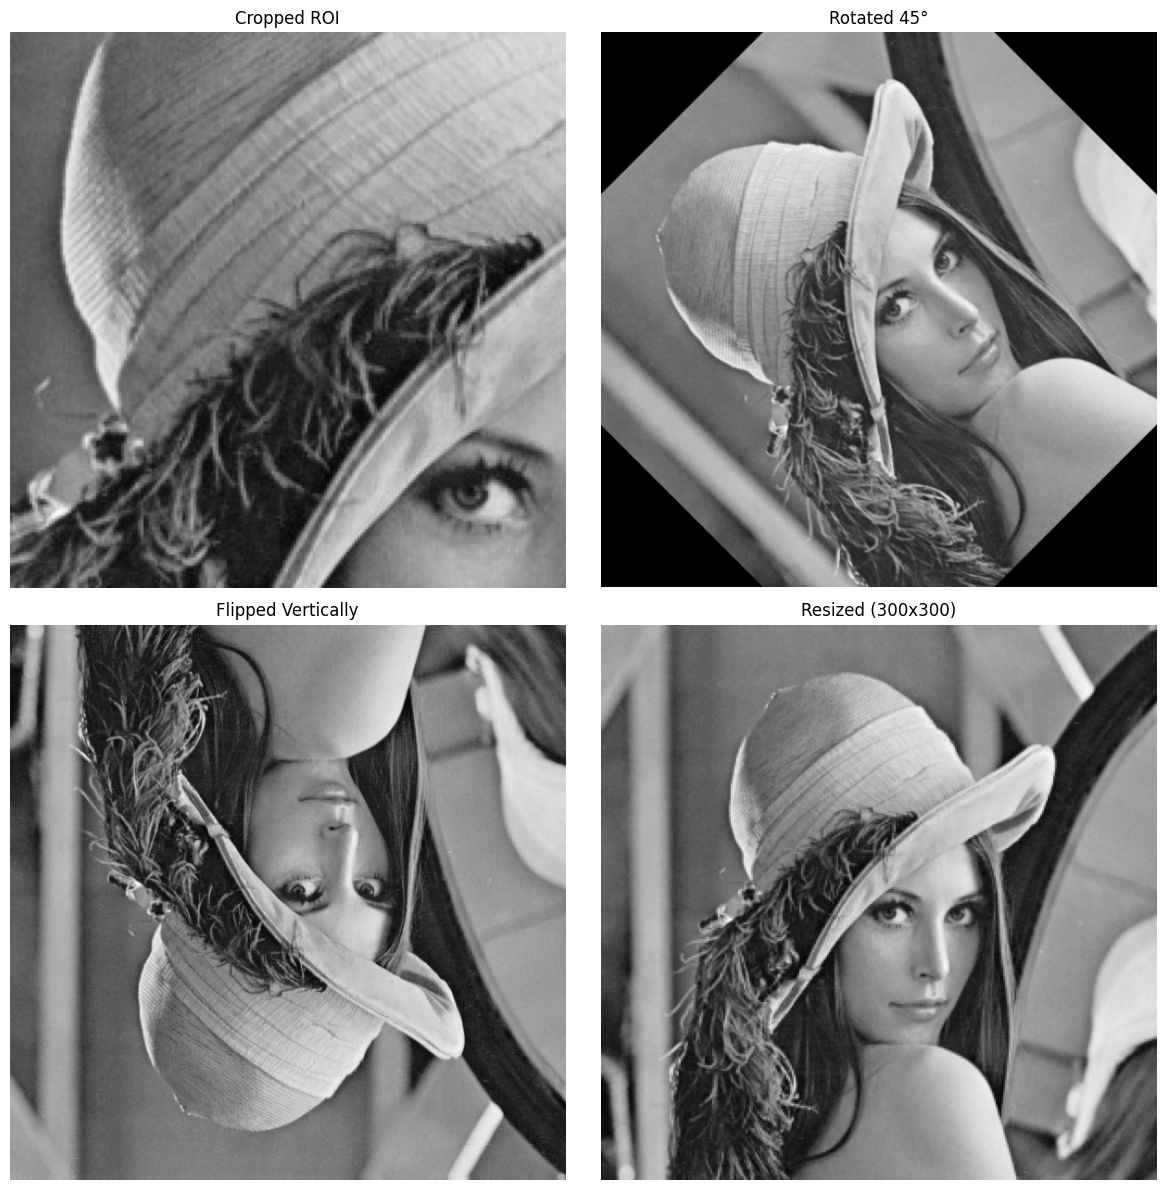

Exercise 2 completed successfully


In [104]:
# Test Exercise 2: Convert to grayscale and apply transformations | 测试练习 2：转换为灰度图并应用变换
print('Exercise 2: Grayscale and Manipulations')
try:
    # Load original image to show its size | 加载原始图像以显示其大小
    original_img = cv2.imread(image_path)
    print(f'Original image size: {original_img.shape[1]}x{original_img.shape[0]} (width x height)')
    print(f'原始图像大小: {original_img.shape[1]}x{original_img.shape[0]} (宽 x 高)')
    
    # Apply all transformations | 应用所有变换
    # roi=(x, y, width, height): crop from (100,100) with 200x200 size | roi=(x, y, 宽, 高): 从(100,100)裁剪200x200区域
    cropped, rotated, flipped, resized = convert_to_grayscale_and_manipulate(
        image_path,
        new_size=(300, 300),
        rotate_angle=45,
        roi=(100, 100, 200, 200)
    )
    
    # Print result sizes | 打印结果大小
    print(f'Cropped size: {cropped.shape[1]}x{cropped.shape[0]}')
    print(f'Rotated size: {rotated.shape[1]}x{rotated.shape[0]}')
    print(f'Flipped size: {flipped.shape[1]}x{flipped.shape[0]}')
    print(f'Resized size: {resized.shape[1]}x{resized.shape[0]}')
    print(f'裁剪后大小: {cropped.shape[1]}x{cropped.shape[0]}')
    print(f'旋转后大小: {rotated.shape[1]}x{rotated.shape[0]}')
    print(f'翻转后大小: {flipped.shape[1]}x{flipped.shape[0]}')
    print(f'调整后大小: {resized.shape[1]}x{resized.shape[0]}')
    
    # Display all results in a 2x2 grid | 在 2x2 网格中显示所有结果
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    axes[0, 0].imshow(cropped, cmap='gray')
    axes[0, 0].set_title('Cropped ROI')
    axes[0, 0].axis('off')
    axes[0, 1].imshow(rotated, cmap='gray')
    axes[0, 1].set_title('Rotated 45°')
    axes[0, 1].axis('off')
    axes[1, 0].imshow(flipped, cmap='gray')
    axes[1, 0].set_title('Flipped Vertically')
    axes[1, 0].axis('off')
    axes[1, 1].imshow(resized, cmap='gray')
    axes[1, 1].set_title('Resized (300x300)')
    axes[1, 1].axis('off')
    plt.tight_layout()
    plt.show()
    
    print('Exercise 2 completed successfully')
except Exception as e:
    print(f'Error in Exercise 2: {e}')

Exercise 3: Gaussian Blur and Edge Detection


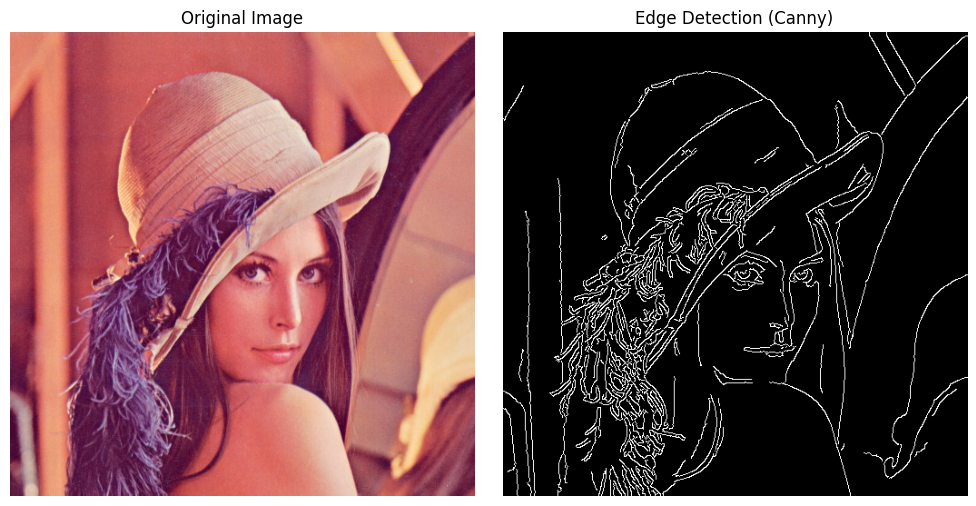

Exercise 3 completed successfully


In [105]:
# Test Exercise 3: Apply Gaussian blur and detect edges | 测试练习 3：应用高斯模糊并检测边缘
print('Exercise 3: Gaussian Blur and Edge Detection')
try:
    # Apply blur and edge detection | 应用模糊和边缘检测
    edges = apply_gaussian_blur_and_edge_detection(
        image_path,
        blur_ksize=5,
        edge_threshold1=50,
        edge_threshold2=150
    )
    
    # Display original and edge-detected images side by side | 并排显示原图和边缘检测结果
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    original = cv2.imread(image_path)
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB because OpenCV uses BGR while matplotlib expects RGB | 将 BGR 转换为 RGB，因为 OpenCV 使用 BGR 而 matplotlib 期望 RGB
    plt.imshow(original_rgb)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(edges, cmap='gray')
    plt.title('Edge Detection (Canny)')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    print('Exercise 3 completed successfully')
except Exception as e:
    print(f'Error in Exercise 3: {e}')